In [10]:
import numpy as np
import matplotlib.pyplot as plt


In [11]:
grid_size = 5
start_state = (0, 0)
goal_state = (grid_size - 1, grid_size - 1)
obstacle_state = (2, 2)


In [12]:
actions = {0: 'Up', 1: 'Down', 2: 'Left', 3: 'Right'}
num_actions = len(actions)


In [13]:
q_table = np.zeros((grid_size, grid_size, num_actions))


In [14]:
learning_rate = 0.1
discount_factor = 0.9
epsilon = 0.1 # Epsilon-greedy exploration



In [15]:
def train_q_learning(episodes=200):
    rewards_per_episode = []

    for episode in range(episodes):
        current_state = start_state
        done = False
        episode_reward = 0

        while not done:
            # Epsilon-greedy action selection
            if np.random.uniform(0, 1) < epsilon:
                action = np.random.randint(num_actions) # Explore
            else:
                action = np.argmax(q_table[current_state]) # Exploit

            # Simulate action and get next state and reward
            next_state, reward, done = take_action(current_state, action)
            episode_reward += reward

            # Q-value update
            old_q_value = q_table[current_state][action]
            next_max_q = np.max(q_table[next_state])
            new_q_value = old_q_value + learning_rate * (reward + discount_factor * next_max_q - old_q_value)
            q_table[current_state][action] = new_q_value

            current_state = next_state

        rewards_per_episode.append(episode_reward)
    return rewards_per_episode


In [16]:
def take_action(state, action):
    row, col = state
    new_row, new_col = row, col
    reward = -1 # Default step reward
    done = False

    if actions[action] == 'Up':
        new_row = max(0, row - 1)
    elif actions[action] == 'Down':
        new_row = min(grid_size - 1, row + 1)
    elif actions[action] == 'Left':
        new_col = max(0, col - 1)
    elif actions[action] == 'Right':
        new_col = min(grid_size - 1, col + 1)

    next_state = (new_row, new_col)

    if next_state == goal_state:
        reward = 10
        done = True
    elif next_state == obstacle_state:
        reward = -5
        done = True
    elif next_state == state and (new_row != row or new_col != col): # Hit a wall
        reward = -5
        done = False # Agent can still move from this state

    return next_state, reward, done

In [17]:
rewards = train_q_learning(episodes=200)


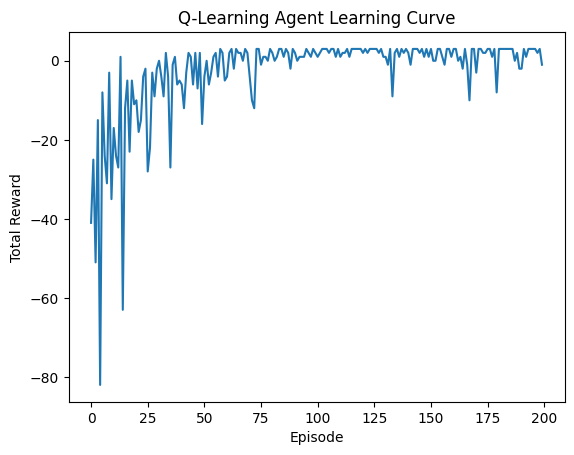

In [18]:
plt.plot(rewards)
plt.xlabel('Episode')
plt.ylabel('Total Reward')
plt.title('Q-Learning Agent Learning Curve')
plt.show()


In [21]:
# Final performance (example path)
current_state = start_state
path = [current_state]
done = False
while not done:
    action = np.argmax(q_table[current_state])
    next_state, _, done = take_action(current_state, action)
    path.append(next_state)
    current_state = next_state
    if len(path) > (grid_size * grid_size) * 2: # Prevent infinite loop in case of bad policy
        break

In [20]:
print("Learned Path:")
for state in path:
    print(state)

Learned Path:
(0, 0)
(0, 1)
(0, 2)
(1, 2)
(1, 3)
(1, 4)
(2, 4)
(3, 4)
(4, 4)
